In [81]:
%matplotlib notebook

import numpy as np
from matplotlib import pyplot as plt

from mmkin import *
from scipy import optimize

Things to fix:

1. negative drifting baseline
2. blank?
3. be smarter about number of data points used to fit

In [101]:
#mutant = 'wt'
#mutant = 'N214A'
#mutant = 'Q256A'
mutant = 'S284A'

if mutant == 'wt':
    ks = KineticsSeries('./wt/wt.yaml', corrections='./config.yaml', prefix='./wt')
elif mutant == 'N214A':
    ks = KineticsSeries('./N214A/n214a.yaml', corrections='./config.yaml', prefix='./N214A')
elif mutant == 'Q256A':
    ks = KineticsSeries('./Q256A/q256a.yaml', corrections='./config.yaml', prefix='./Q256A')
elif mutant == 'S284A':
    ks = KineticsSeries('./S284A/s284a.yaml', corrections='./config.yaml', prefix='./S284A')
else:
    raise NameError()

Loading: 210422_20_10_5_and_2µM_MproS284A.csv...
 ... excluded
Loading: 210430_buffer_160_80_and_40µM_MproS284A.csv...
Loading: 210430_20_10_5_and_2µM_MproS284A.csv...
Loading: 210507_buffer_20µM_MproWT_N_Q_S.csv...
 ... excluded
Loading: 210507_10µM_MproWT_N_Q_S.csv...
 ... excluded


In [102]:
ps = [5.0, 10.0, 20.0, 40.0, 80.0, 160.0]
#ps = [10.0, 20.0, 40.0, 80.0, 160.0]
ss = np.array([320.0, 160.0, 80.0, 40.0, 20.0, 10.0, 5.0])

n_p = len(ps)
n_s = len(ss)
print(n_p, n_s)

ks.fit_v0(r2_threshold=0.5)

6 7


<IPython.core.display.Javascript object>


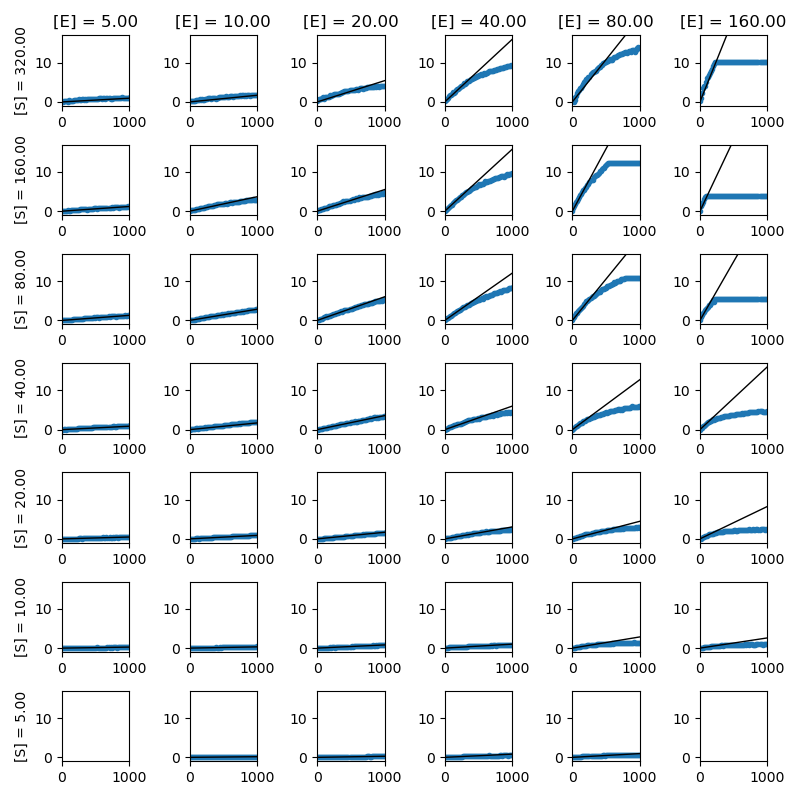

In [103]:
fig, axes = plt.subplots(n_s, n_p, figsize=(8,8))

for i_p,p in enumerate(ps):
    for i_s,s in enumerate(ss):
        
        v0_set = []
        
        for entry in ks.get(p, s):
            
            if i_s == 0:
                axes[i_s, i_p].set_title('[E] = %.2f' % p)
            if i_p == 0:
                axes[i_s, i_p].set_ylabel('[S] = %.2f' % s)
                
            axes[i_s, i_p].set_xlim([0, 1000])
            axes[i_s, i_p].set_ylim([-1, 17])
            
            if entry['exclude']:
                continue
            
            t = entry['dt'] * np.arange(len(entry['timeseries']))
            axes[i_s, i_p].plot(t, entry['timeseries'], '.')
            axes[i_s, i_p].plot(t, entry['v0'] * t, color='k', lw=1)
            
plt.tight_layout()
#plt.savefig('figures/%s_traces.pdf' % mutant)
plt.show()

<IPython.core.display.Javascript object>


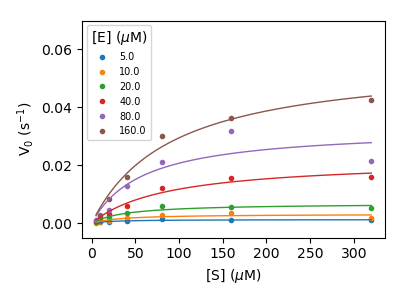

[E]	k_cat		K_m
---	-----		---
5.00	2.57e-04	2.30e+01
10.00	3.16e-04	3.31e+01
20.00	3.45e-04	3.99e+01
40.00	5.51e-04	8.73e+01
80.00	4.12e-04	5.90e+01
160.00	3.53e-04	9.16e+01


In [109]:
kinetic_params = np.zeros([n_p, 3])

plt.figure(figsize=(4,3))

ax1 = plt.subplot(111)
for p in ps:
    s0s, _, v0s = ks.get_set_v0s([p], ss)
    ax1.plot(s0s, v0s, '.')
    
ax1.set_ylim([-0.005, 0.07])
    
ax1.set_xlabel('[S] ($\mu$M)')
ax1.set_ylabel('V$_0$ (s$^{-1}$)')

ax1.legend(ps, title='[E] ($\mu$M)', fontsize=7, loc=2)

# fit
print('[E]\tk_cat\t\tK_m')
print('---\t-----\t\t---')

plt.gca().set_prop_cycle(None)
for i,p in enumerate(ps):
    
    s0s, _, v0s = ks.get_set_v0s([p], ss)
    
    k_cat, K_m = fit_mm(v0s, s0s, p)
    print('%.2f\t%.2e\t%.2e' % (p, k_cat, K_m))
    kinetic_params[i,:] = np.array([p, k_cat, K_m])
    
    S = np.linspace(ss.min(), ss.max(), 100)
    V_fit = mm(p, S, k_cat, K_m)
    ax1.plot(S, V_fit, lw=1)

    
plt.tight_layout()
plt.savefig('figures/%s_mm.pdf' % mutant)
plt.show()

<IPython.core.display.Javascript object>


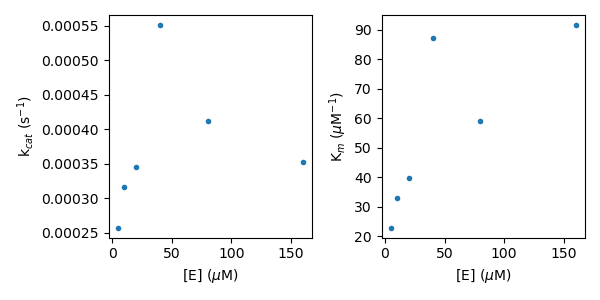

In [105]:
plt.figure(figsize=(6,3))

plt.subplot(121)
plt.plot(kinetic_params[:,0], kinetic_params[:,1], '.')
plt.xlabel('[E] ($\mu$M)')
plt.ylabel('k$_{cat}$ (s$^{-1}$)')

plt.subplot(122)
plt.plot(kinetic_params[:,0], kinetic_params[:,2], '.')
plt.xlabel('[E] ($\mu$M)')
plt.ylabel('K$_m$ ($\mu$M$^{-1}$)')

plt.tight_layout()
plt.show()

## Haldane

<IPython.core.display.Javascript object>


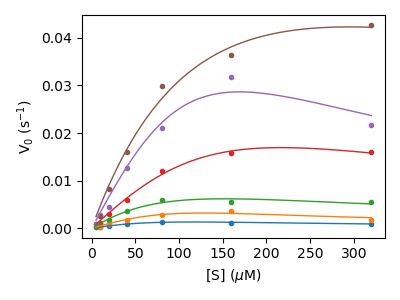

[E]	k_cat		K_m		K_i
---	-----		---		---
5.00	1.25e-03	2.19e+02	6.18e+01
10.00	1.02e-02	1.97e+03	8.29e+00
20.00	1.13e-03	2.00e+02	1.15e+02
40.00	6.48e-03	1.55e+03	3.03e+01
80.00	2.31e+00	5.45e+05	5.26e-02
160.00	6.12e-04	1.94e+02	4.48e+02


In [106]:
haldane_params = np.zeros([n_p, 4])

plt.figure(figsize=(4,3))

ax1 = plt.subplot(111)
for p in ps:
    s0s, _, v0s = ks.get_set_v0s([p], ss)
    ax1.plot(s0s, v0s, '.')
ax1.set_xlabel('[S] ($\mu$M)')
ax1.set_ylabel('V$_0$ (s$^{-1}$)')

# fit
print('[E]\tk_cat\t\tK_m\t\tK_i')
print('---\t-----\t\t---\t\t---')

plt.gca().set_prop_cycle(None)
for i,p in enumerate(ps):
    
    s0s, _, v0s = ks.get_set_v0s([p], ss)
    
    k_cat, K_m, K_i = fit_haldane(v0s, s0s, p)
    print('%.2f\t%.2e\t%.2e\t%.2e' % (p, k_cat, K_m, K_i))
    haldane_params[i,:] = np.array([p, k_cat, K_m, K_i])
    
    S = np.linspace(ss.min(), ss.max(), 100)
    V_fit = haldane(p, S, k_cat, K_m, K_i)
    ax1.plot(S, V_fit, lw=1)
    

plt.tight_layout()
#plt.savefig('figures/%s_haldane.pdf' % mutant)
plt.show()

<IPython.core.display.Javascript object>


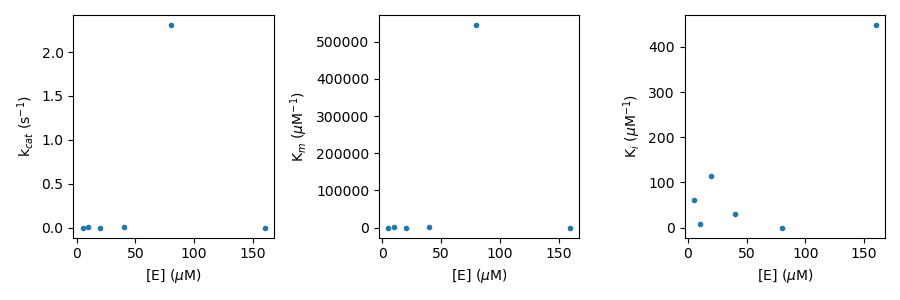

In [107]:
plt.figure(figsize=(9,3))

plt.subplot(131)
plt.plot(haldane_params[:,0], haldane_params[:,1], '.')
plt.xlabel('[E] ($\mu$M)')
plt.ylabel('k$_{cat}$ (s$^{-1}$)')

plt.subplot(132)
plt.plot(haldane_params[:,0], haldane_params[:,2], '.')
plt.xlabel('[E] ($\mu$M)')
plt.ylabel('K$_m$ ($\mu$M$^{-1}$)')

plt.subplot(133)
plt.plot(haldane_params[:,0], haldane_params[:,3], '.')
plt.xlabel('[E] ($\mu$M)')
plt.ylabel('K$_i$ ($\mu$M$^{-1}$)')

plt.tight_layout()
plt.show()